# **Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Load Dataset**

In [2]:
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Customer_Segmentation_and_Retention_Analysis/Online Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


# **Data Cleaning**

In [6]:
# drop rows with missing customerID
df = df.dropna(subset=['CustomerID'])
df.shape

(406829, 8)

In [7]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [10]:
(df['Quantity']<=0).sum()

np.int64(8905)

In [11]:
# remove negetive quantities(returns)
df = df[df['Quantity']>0]
df.shape

(397924, 8)

In [12]:
# create total price column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


# **Create RFM Features**

In [19]:
# define a reference date
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:50:00')

In [26]:
# create RFM Table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [28]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4339 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4339 non-null   int64  
 1   Frequency  4339 non-null   int64  
 2   Monetary   4339 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 135.6 KB


# **Feature Scaling**

In [30]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [31]:
# covert in into dataframe
rfm_scaled = pd.DataFrame(rfm_scaled, columns=rfm.columns, index=rfm.index)
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334858,-0.424675,8.359634
12347.0,-0.905199,0.354080,0.251046
12348.0,-0.175186,-0.035297,-0.028546
12349.0,-0.735196,-0.424675,-0.032963
12350.0,2.174855,-0.424675,-0.191315


# **Find the best number of clusters**

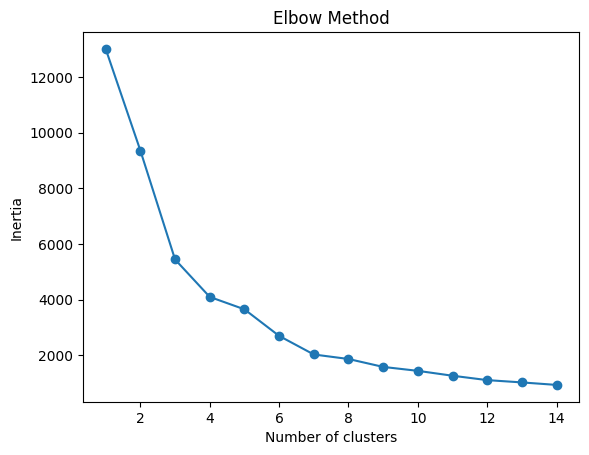

In [32]:
from sklearn.cluster import KMeans
inertia = []
for k in range(1,15):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(rfm_scaled)
  inertia.append(kmeans.inertia_)

plt.plot(range(1,15), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# **Apply K-Means(K=4)**

In [60]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,0
12347.0,2,7,4310.00,3
12348.0,75,4,1797.24,3
12349.0,19,1,1757.55,3
12350.0,310,1,334.40,1


In [61]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,15.672986,22.047393,12453.225924
1,248.564030,1.551789,478.107581
2,7.384615,82.692308,127338.313846
3,43.910580,3.655748,1349.698298


In [62]:
cluster_map = {
    0: 'Loyal',
    1: 'Lost',
    2: 'VIP',
    3: 'Potential'
}
rfm['CustomerSegment'] = rfm['Cluster'].map(cluster_map)
rfm.head()

,Recency,Frequency,Monetary,Cluster,CustomerSegment
CustomerID,,,,,
12346.0,326,1,77183.60,0,Loyal
12347.0,2,7,4310.00,3,Potential
12348.0,75,4,1797.24,3,Potential
12349.0,19,1,1757.55,3,Potential
12350.0,310,1,334.40,1,Lost


# **Visualisation**

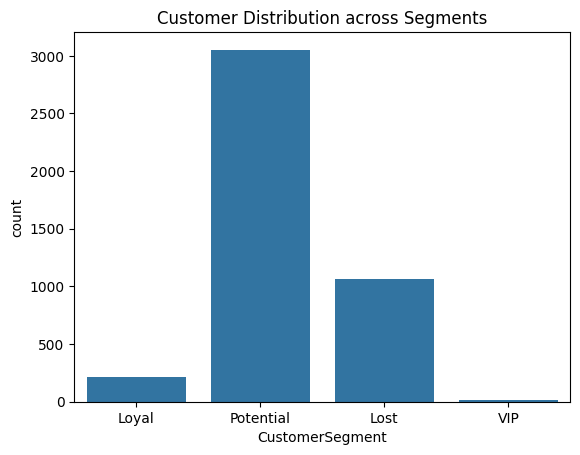

In [64]:
# Customer Distribution
sns.countplot(x='CustomerSegment', data=rfm)
plt.title('Customer Distribution across Segments')
plt.show()

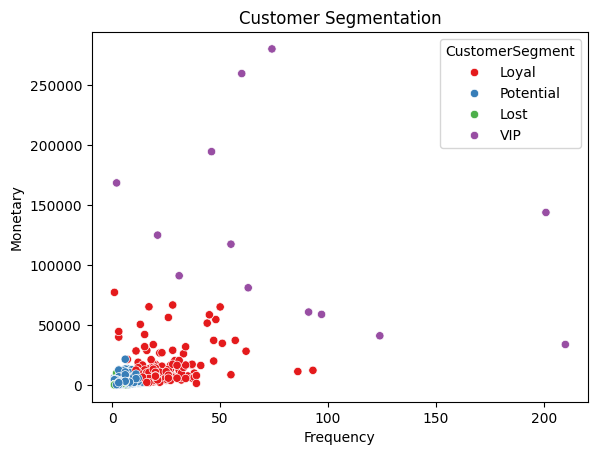

In [66]:
# Customer Segmentation scatter plot
sns.scatterplot(x='Frequency', y='Monetary', hue='CustomerSegment', data=rfm , palette='Set1')
plt.title('Customer Segmentation')
plt.show()